**Analiza Poker Hand History dataset-a**

Ovaj notebook sadrži analizu podataka iz fajla `poker_hand_history_dataset.csv` i služi kao prva faza projekta za detekciju blefa u Texas Hold'em pokeru.

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast

CSV_PATH = "../data/poker_hand_history_dataset.csv"

# Helper funkcija za konverziju stringova u liste
def str_to_list(x):
    try:
        return ast.literal_eval(x) if isinstance(x, str) else x
    except Exception:
        return []

converters = {
    "blinds_or_straddles": str_to_list,
    "starting_stacks": str_to_list,
    "seats": str_to_list,
    "players": str_to_list,
    "actions": str_to_list,
    "winnings": str_to_list,
}

# Učitavanje podataka
df = pd.read_csv(CSV_PATH, converters=converters)
df.head()

,hand,venue,day,month,year,blinds_or_straddles,min_bet,starting_stacks,seats,players,actions,winnings
0,3017243282,Absolute Poker,1,7,2009,"[3, 6, 0, 0, 0, 0]",6.0,"[798, 648, 873, 950, 1804.15, 612.5]","[3, 4, 5, 6, 1, 2]","[4Aqgslf5pr+41H/LL6IM1Q, /P+7Z0P/b7YiK60FW9dRA...","[d dh p1 ????, d dh p2 ????, d dh p3 ????, d d...","[0, 0, 0, 0, 0, 15]"
1,3017244774,Absolute Poker,1,7,2009,"[3, 6, 0, 0, 0, 0]",6.0,"[642, 873, 950, 1804.15, 621.5, 795]","[4, 5, 6, 1, 2, 3]","[/P+7Z0P/b7YiK60FW9dRAQ, ouQv0Sc4aPg8AuwhCk+lm...","[d dh p1 ????, d dh p2 ????, d dh p3 ????, d d...","[0, 0, 36.55, 0, 0, 0]"
2,3017247534,Absolute Poker,1,7,2009,"[3, 6, 0, 0, 0, 0]",6.0,"[861, 974.55, 1792.15, 621.5, 795, 639]","[5, 6, 1, 2, 3, 4]","[ouQv0Sc4aPg8AuwhCk+lmw, /o9PHqbg1NCh2sSuutI0l...","[d dh p1 ????, d dh p2 ????, d dh p3 ????, d d...","[0, 9, 0, 0, 0, 0]"
3,3017249110,Absolute Poker,1,7,2009,"[3, 6, 0, 0, 0, 0]",6.0,"[977.55, 1792.15, 621.5, 795, 639, 858]","[6, 1, 2, 3, 4, 5]","[/o9PHqbg1NCh2sSuutI0lw, uv/AgWLwKp7QHpZqFP1yA...","[d dh p1 ????, d dh p2 ????, d dh p3 ????, d d...","[0, 0, 0, 0, 0, 42.25]"
4,3017252962,Absolute Poker,1,7,2009,"[3, 6, 0, 0, 0, 0]",6.0,"[1771.15, 621.5, 795, 639, 879.25, 974.55]","[1, 2, 3, 4, 5, 6]","[uv/AgWLwKp7QHpZqFP1yAg, uUr5VW+nLr7e9CueUrQ47...","[d dh p1 ????, d dh p2 ????, d dh p3 ????, d d...","[0, 0, 0, 0, 0, 140.5]"


**Osnovne informacije o podacima**

In [10]:
print("Oblik (broj ruku, broj kolona):", df.shape)
print("Kolone:", list(df.columns))
print("Primer ruke:\n", df.iloc[0])
print("Broj ruku:", len(df))
print("Venues (broj ruku po sajtu):", df['venue'].value_counts())

Oblik (broj ruku, broj kolona): (199631, 12)
Kolone: ['hand', 'venue', 'day', 'month', 'year', 'blinds_or_straddles', 'min_bet', 'starting_stacks', 'seats', 'players', 'actions', 'winnings']
Primer ruke:
 hand                                                          3017243282
venue                                                     Absolute Poker
day                                                                    1
month                                                                  7
year                                                                2009
blinds_or_straddles                                   [3, 6, 0, 0, 0, 0]
min_bet                                                              6.0
starting_stacks                     [798, 648, 873, 950, 1804.15, 612.5]
seats                                                 [3, 4, 5, 6, 1, 2]
players                [4Aqgslf5pr+41H/LL6IM1Q, /P+7Z0P/b7YiK60FW9dRA...
actions                [d dh p1 ????, d dh p2 ????, d dh p3 ????,

**Inženjering osnovnih feature-a: broj igrača, prosečan stack, veliki blind, ukupna vrednost pota**

In [3]:
df["broj_igraca"] = df["players"].apply(len)
df["prosecni_stack"] = df["starting_stacks"].apply(lambda x: sum(x)/len(x) if isinstance(x, list) and len(x)>0 else 0)
df["veliki_blind"] = df["blinds_or_straddles"].apply(lambda x: max(x) if isinstance(x, list) and len(x)>0 else 0)
df["pot_vrednost"] = df["winnings"].apply(lambda x: sum(x) if isinstance(x, list) else 0)

df[["broj_igraca", "prosecni_stack", "veliki_blind", "pot_vrednost"]].describe()

,broj_igraca,prosecni_stack,veliki_blind,pot_vrednost
count,199631.000000,199631.000000,199631.000000,199631.000000
mean,5.650245,166.238300,1.050633,6.195882
std,2.286254,357.703640,1.650940,27.799700
min,2.000000,6.100000,0.250000,0.000000
25%,4.000000,43.641250,0.500000,0.750000
50%,6.000000,55.840000,0.500000,1.250000
75%,8.000000,75.086000,0.500000,4.050000
max,9.000000,3537.943333,6.000000,2000.000000


- Broj igrača: U proseku 5.65 igrača po ruci (raspon od 2 do 9, što je normalno).
- Prosečan stack: Prosek 166 žetona, ali sa velikim standardnim devijacijama - što ukazuje na oscilacije stackova između partija, posebno na višim blindovima ili u dubokim stack igrama.
- Veliki blind: Prosečan BB je 1.05, ali varira do 6 (multiple stakes u bazi).
- Vrednost pota: Većina ruku ima nizak pot (prosek 6.2), ali maksimum je čak 2000 (outliers).

**Distribucija broja igrača po ruci**

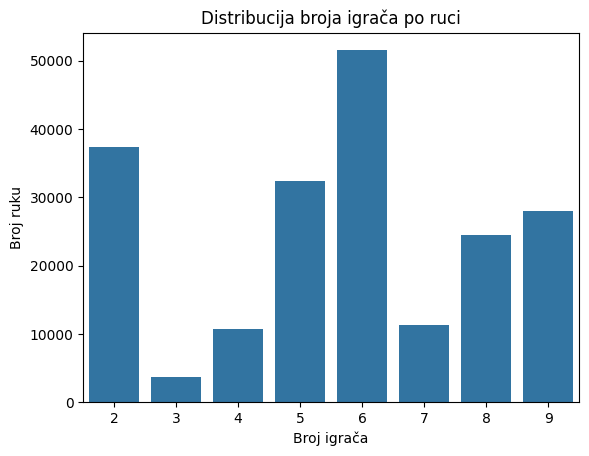

In [4]:
sns.countplot(x="broj_igraca", data=df)
plt.title("Distribucija broja igrača po ruci")
plt.xlabel("Broj igrača")
plt.ylabel("Broj ruku")
plt.show()

- Najčešće su partije sa 6 igrača (~52.000 ruku) ili 2 igrača (~38.000 ruku), sledećih najviše su 5, 8, 9 itd.
- Six-max (6 igrača) je najzastupljeniji oblik stola - to su najreprezentativnije NLHE cash/tourney varijante online.
- Dobar je uzorak i za heads-up (2 igrača), kao i za analiziranje dinamike na full ring (8-9 igrača).

**Parsiranje akcija i analiza agresivnosti**

In [5]:
def parse_actions(actions):
    if not isinstance(actions, list):
        try:
            actions = ast.literal_eval(actions)
        except Exception:
            return {"bet":0, "raise":0, "fold":0, "showdown":0, "agresivno":0}
    bet, raise_, fold, showdown, agresivno = 0, 0, 0, 0, 0
    for act in actions:
        act_l = act.lower()
        if "cbr" in act_l or "bet" in act_l:
            bet += 1
            agresivno += 1
        if "raise" in act_l:
            raise_ += 1
            agresivno += 1
        if "f" in act_l and "fold" in act_l or act_l.endswith(" f"):
            fold += 1
        if "sm" in act_l:
            showdown += 1
    return {"bet":bet, "raise":raise_, "fold":fold, "showdown":showdown, "agresivno":agresivno}

rekap = df["actions"].apply(parse_actions).apply(pd.Series)
for col in ["bet","raise","fold","showdown","agresivno"]:
    df[col] = rekap[col]

df[["bet","raise","fold","showdown","agresivno"]].describe()

,bet,raise,fold,showdown,agresivno
count,199631.000000,199631.0,199631.000000,199631.000000,199631.000000
mean,1.582159,0.0,4.420591,0.584794,1.582159
std,1.184342,0.0,2.279745,1.348438,1.184342
min,0.000000,0.0,0.000000,0.000000,0.000000
25%,1.000000,0.0,3.000000,0.000000,1.000000
50%,1.000000,0.0,5.000000,0.000000,1.000000
75%,2.000000,0.0,6.000000,0.000000,2.000000
max,9.000000,0.0,8.000000,12.000000,9.000000


- Prosečno 1.58 "betova" po ruci (rang 0–9)
- Foldova prosek: 4.4 – što odgovara prosečnim partijama sa većim brojem igrača.
- Showdown akcija se događa tek kod oko 0.58 ruku po partiji – znači većina ruku završi bez pokazivanja karata (fold pre showdown-a).
- Ukupna agresivnost (agresivno = bet + raise): 1.58, što prilično dobro korespondira sa brojem betova i izostankom raise-a.

**Vizualizacija agresivnosti**

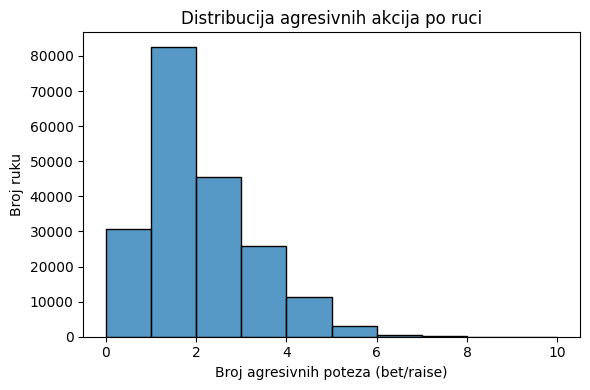

In [6]:
plt.figure(figsize=(6,4))
sns.histplot(df['agresivno'], bins=range(0,df['agresivno'].max()+2), kde=False)
plt.title("Distribucija agresivnih akcija po ruci")
plt.xlabel("Broj agresivnih poteza (bet/raise)")
plt.ylabel("Broj ruku")
plt.tight_layout()
plt.show()

- Najviše ruku ima 1 ili 2 agresivna poteza, što je u skladu sa No-Limit Hold'em dinamikom (npr. bet ili raise na jednoj od ulica, često bez daljeg zatezanja).
- Značajan broj ruku ima 0 agresivnih poteza (niko nije uložio, svi čekirali/foladovali).
- Manje je onih ruku sa više agresivnih akcija, što obično označava veće partije ili više igrača uključenih do kraja.
- Ruku sa preko 5 agresivnih aksiја ima mnogo manje – što su izuzetno retke, visoko-zategnute situacije ili multiway potezi.

**Analiza broja showdown ruku**

In [7]:
pokazivanje_karte_pct = (df['showdown']>0).mean()*100
print("Procenat ruku gde je bilo pokazivanja karata (showdown):", round(pokazivanje_karte_pct,2), "%")

Procenat ruku gde je bilo pokazivanja karata (showdown): 21.63 %


Samo otprilike svaki peti pot završi pokazivanjem karata. U ogromnoj većini ruku, ruka se završi bez showdown-a (protivnici foldaju ranije).

**Identifikacija mogućih blef ruku**

Procenat ruku sa mogućim blefom (gruba heuristika): 66.37 %


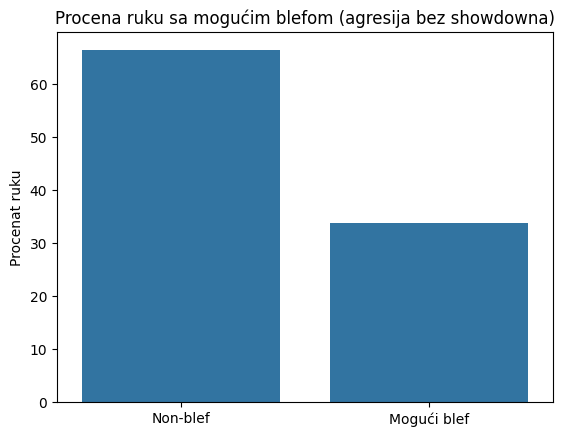

In [8]:
df["moguci_blef"] = ((df['showdown']==0) & (df['agresivno']>0)).astype(int)
blef_pct = df['moguci_blef'].mean()*100
print("Procenat ruku sa mogućim blefom (gruba heuristika):", round(blef_pct,2), "%")

sns.barplot(x=["Non-blef","Mogući blef"], y=df["moguci_blef"].value_counts(normalize=True).values*100)
plt.ylabel("Procenat ruku")
plt.title("Procena ruku sa mogućim blefom (agresija bez showdowna)")
plt.show()

- Oko 66% ruku su “non-blef” po ovoj detekciji — tj. nisu imale agresivnu akciju bez showdowna.
- Oko 33% ruku su “mogući blef” — bar jedan bet/raise, ali igrač nije morao da pokaže karte (možda su foldovi ispratili potez).

Ovo samo pokazuje da je u 33% ruka bilo uslova za blefiranje (agresija, bez showdowna, protivnici odustali).